In [1]:
import matplotlib.pyplot as plt
import numpy as np
%matplotlib inline
import os

In [2]:
import sys
sys.path.insert(1, '../detectability')

import resonance
from resonance import System, Filter, phase_diff_t_shift

from pycbc.psd.read import from_txt

/home/alberto/ns-resonance/jupyter-env/lib/python3.12/site-packages/pycbc/types/array.py:36: UserWarning: Wswiglal-redir-stdio:

SWIGLAL standard output/error redirection is enabled in IPython.
This may lead to performance penalties. To disable locally, use:

with lal.no_swig_redirect_standard_output_error():
    ...

To disable globally, use:

lal.swig_redirect_standard_output_error(False)

Note however that this will likely lead to error messages from
LAL functions being either misdirected or lost when called from
Jupyter notebooks.

To suppress this warning, use:

import warnings
warnings.filterwarnings("ignore", "Wswiglal-redir-stdio")
import lal

  import lal as _lal
PyCBC.libutils: pkg-config call failed, setting NO_PKGCONFIG=1


# Inputs

In [3]:
f_low, f_high, tlen, srate, dL, approximant, detector = [10, 1024, 512, 1024*16, 100, 'IMRPhenomD', 'aLIGO/Asharp_strain']

##isue for srate=1024
filt = Filter(f_low, f_high, tlen, srate, dL, approximant, detector) 

Requested number of samples exceeds the highest available frequency in the input data, will use max available frequency instead. (requested 8192.000000 Hz, available 6000.000000 Hz)
/home/alberto/ns-resonance/jupyter-env/lib/python3.12/site-packages/pycbc/types/array.py:390: RuntimeWarning: divide by zero encountered in divide
  return self._data.__rtruediv__(other)


In [4]:
def non_zero_val(detector):
    filt.detector = detector
    # find indices where f != 0
    nonzero_idxs = np.nonzero(filt.psd)[0]  # [0] to get the index array
    
    if nonzero_idxs.size > 0:
        i = nonzero_idxs[0]    # first index where f != 0
        x1 = filt.freqs[i]
        print("First nonzero at index", i, "f-min =", x1, "psd value",filt.psd[i])
    else:
        print("f(x) is zero everywhere!")

    return x1, filt.psd[i], i

# Generate data

Requested number of samples exceeds the highest available frequency in the input data, will use max available frequency instead. (requested 8192.000000 Hz, available 4995.378000 Hz)


First nonzero at index 5120 f-min = 10.0 psd value 1.104690514402604e-43


Requested number of samples exceeds the highest available frequency in the input data, will use max available frequency instead. (requested 8192.000000 Hz, available 5000.000000 Hz)


First nonzero at index 512 f-min = 1.0 psd value 2.305203613151304e-41
First nonzero at index 3072 f-min = 6.0 psd value 1.2080394560426344e-47


(0.1, 20)

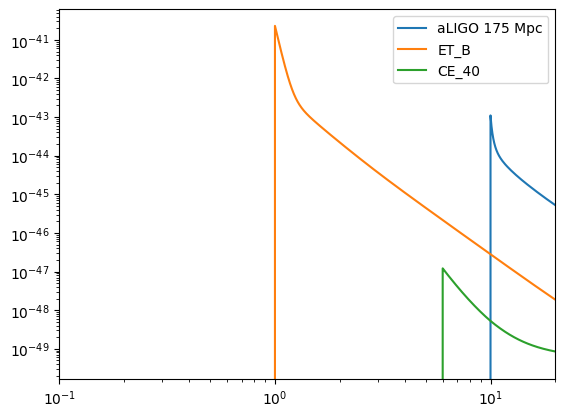

In [5]:
filt.f_low = 10
non_zero_val('aLIGO/aligo_175Mpc')
plt.plot(filt.freqs,filt.psd, label = 'aLIGO 175 Mpc')

filt.f_low = 1
non_zero_val('ET/ET_B')
plt.plot(filt.freqs,filt.psd, label = 'ET_B')

filt.f_low = 6
non_zero_val('CE/CE_40')
plt.loglog(filt.freqs, filt.psd, label = 'CE_40')

plt.legend()
filt.f_low = 15

plt.xlim(0.1,20)

We use Nils article PSDs 

<>:29: SyntaxWarning: invalid escape sequence '\ '
<>:30: SyntaxWarning: invalid escape sequence '\ '
<>:29: SyntaxWarning: invalid escape sequence '\ '
<>:30: SyntaxWarning: invalid escape sequence '\ '
/tmp/ipykernel_9840/3357638713.py:29: SyntaxWarning: invalid escape sequence '\ '
  plt.xlabel('$f \ [Hz]$')
/tmp/ipykernel_9840/3357638713.py:30: SyntaxWarning: invalid escape sequence '\ '
  plt.ylabel('$PSD \ [Hz^{-1}]$')
Requested number of samples exceeds the highest available frequency in the input data, will use max available frequency instead. (requested 8192.000000 Hz, available 5000.000000 Hz)
Requested number of samples exceeds the highest available frequency in the input data, will use max available frequency instead. (requested 8192.000000 Hz, available 4995.378000 Hz)
Requested number of samples exceeds the highest available frequency in the input data, will use max available frequency instead. (requested 8192.000000 Hz, available 5000.000000 Hz)
Requested number of sampl

/home/alberto/ns-resonance/jupyter-env/lib/python3.12/site-packages/IPython/core/events.py:82: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  func(*args, **kwargs)
/home/alberto/ns-resonance/jupyter-env/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


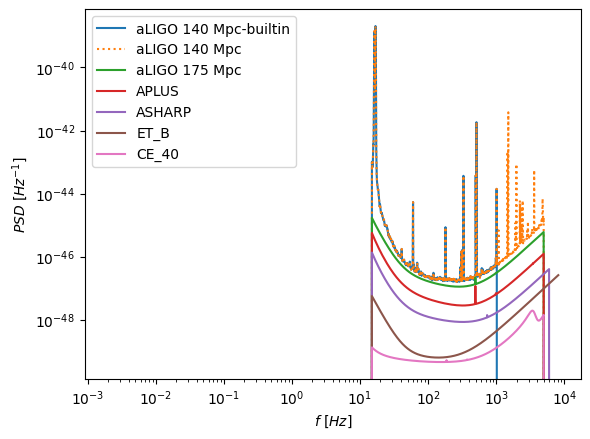

In [6]:
#filt.detector = 'GW170817'
#plt.loglog(filt.freqs, filt.psd, label = 'GW170817')

from pycbc.psd.analytical import aLIGO140MpcT1800545

filt.detector = aLIGO140MpcT1800545
plt.loglog(filt.freqs, filt.psd, label = 'aLIGO 140 Mpc-builtin')

filt.detector = 'aLIGO/aligo_140Mpc'
plt.loglog(filt.freqs, filt.psd, ':', label = 'aLIGO 140 Mpc')

a=max(filt.psd[tlen*f_low:tlen*f_high])
filt.detector = 'aLIGO/aligo_175Mpc'
plt.loglog(filt.freqs, filt.psd, label = 'aLIGO 175 Mpc')

filt.detector = 'aLIGO/AplusDesign'
plt.loglog(filt.freqs, filt.psd, label = 'APLUS')

filt.detector = 'aLIGO/Asharp_strain'
plt.loglog(filt.freqs, filt.psd, label = 'ASHARP')

filt.detector = 'ET/ET_B'
plt.loglog(filt.freqs, filt.psd, label = 'ET_B')

filt.detector = 'CE/CE_40'
plt.loglog(filt.freqs, filt.psd, label = 'CE_40')
b=min(filt.psd[tlen*15:tlen*1024])

plt.xlabel('$f \ [Hz]$')
plt.ylabel('$PSD \ [Hz^{-1}]$')

plt.legend()

#plt.xlim(15,1024)
#plt.ylim(b,a/1000)